In [1]:
# Google Colab instructions
# Runtime > Change Runtime Type > Runtime Version > 2025.07
# This cell should say you're now on Python Version 3.11.

import sys
print(sys.version)

3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]


In [2]:
!pip install pycaret openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 1.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pmdarima to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of pyod to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.2/58.2 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.0/58.0 kB 5.0 MB/s eta 0:00:00


In [1]:
# Before running: Runtime > Restart Session

from pycaret.classification import *

In [2]:
import pandas as pd

df = pd.read_excel("sipri_data1.xlsx")

#US Top Supplier Classification

In [3]:
exp1 = ClassificationExperiment()

exp1.setup(
    data=df,
    target='is_US_top_supplier_country?',
    ignore_features=['country', 'year', 'top_supplier_country'],
    numeric_imputation='mean',
    categorical_imputation='mode',
    session_id=123,
    fix_imbalance=True
)

,Description,Value
0,Session id,123
1,Target,is_US_top_supplier_country?
2,Target type,Binary
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(221, 16)"
5,Transformed train set shape,"(166, 16)"
6,Transformed test set shape,"(55, 16)"
7,Ignore features,3
8,Numeric features,15
9,Rows with missing values,70.0%


In [4]:
# Compare all models

print("Comparing models for 'is_US_top_supplier_country?':")
best_model1 = exp1.compare_models()

Comparing models for 'is_US_top_supplier_country?':


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7744,0.8045,0.7050,0.6730,0.6719,0.5012,0.5206,0.1650
et,Extra Trees Classifier,0.7590,0.8634,0.6600,0.6508,0.6453,0.4625,0.4735,0.2850
xgboost,Extreme Gradient Boosting,0.7429,0.7839,0.6350,0.6339,0.6167,0.4242,0.4415,0.0860
lightgbm,Light Gradient Boosting Machine,0.7429,0.7873,0.6400,0.6406,0.6221,0.4321,0.4473,0.1080
dt,Decision Tree Classifier,0.7372,0.7029,0.6100,0.6064,0.6009,0.4047,0.4116,0.0390
rf,Random Forest Classifier,0.7192,0.8390,0.6850,0.6129,0.6210,0.4051,0.4299,0.2020
knn,K Neighbors Classifier,0.7051,0.7814,0.6850,0.6154,0.6234,0.3941,0.4111,0.0860
ada,Ada Boost Classifier,0.6949,0.7794,0.5450,0.5262,0.5195,0.3023,0.3124,0.1220
qda,Quadratic Discriminant Analysis,0.6808,0.6806,0.5650,0.4671,0.4984,0.2759,0.2970,0.0380
dummy,Dummy Classifier,0.6641,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0310


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [5]:
# Hyperparameter tuning

tuned_model1 = exp1.tune_model(best_model1, optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8462,0.8500,0.6000,1.0000,0.7500,0.6486,0.6928
1,0.6923,0.7750,1.0000,0.5556,0.7143,0.4348,0.5270
2,0.7692,0.7778,0.7500,0.6000,0.6667,0.4935,0.5007
3,0.8462,0.9444,0.5000,1.0000,0.6667,0.5806,0.6396
4,0.8462,0.8333,0.7500,0.7500,0.7500,0.6389,0.6389
5,0.6667,0.9062,0.7500,0.5000,0.6000,0.3333,0.3536
6,0.6667,0.6562,0.2500,0.5000,0.3333,0.1429,0.1581
7,0.5833,0.7188,0.5000,0.4000,0.4444,0.1176,0.1195
8,0.6667,0.8438,0.5000,0.5000,0.5000,0.2500,0.2500


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


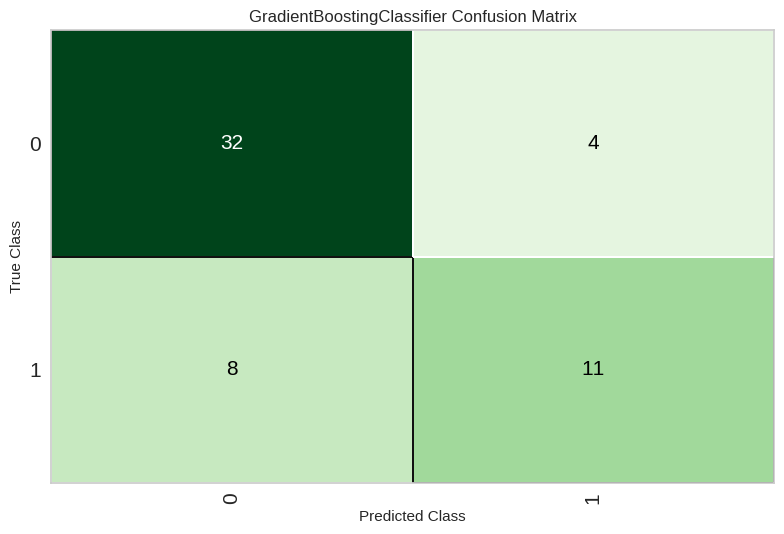

In [6]:
# Confusion Matrix

exp1.plot_model(tuned_model1, plot='confusion_matrix')

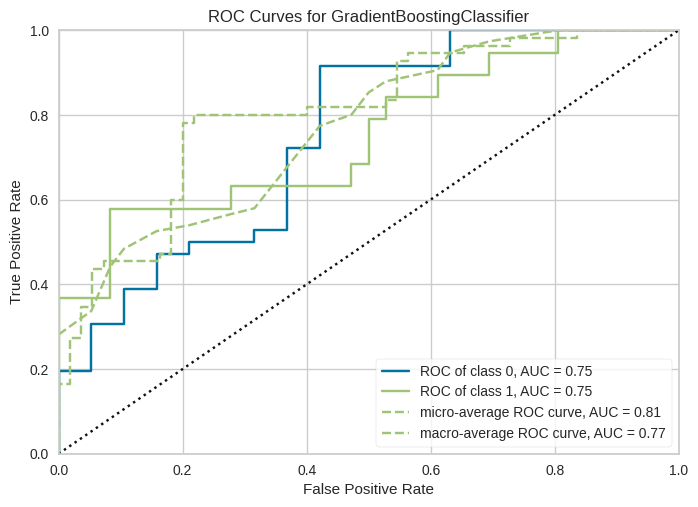

In [7]:
# ROC Curve

exp1.plot_model(tuned_model1, plot='auc')

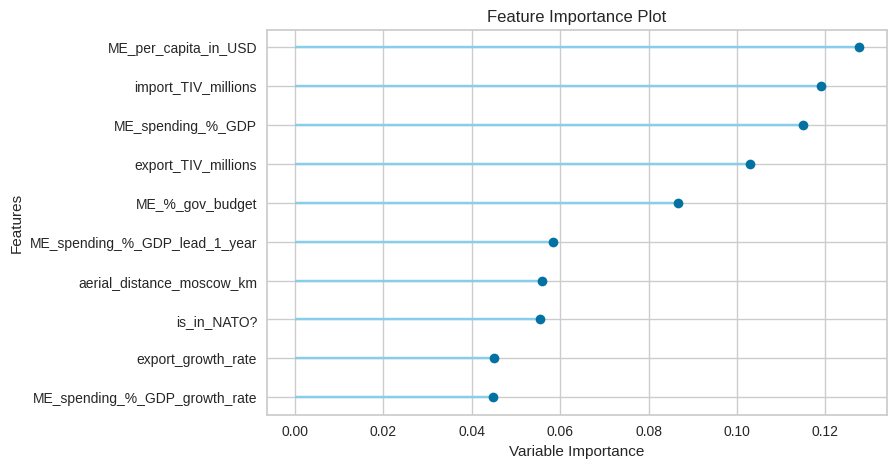

In [8]:
# Features that matter most

exp1.plot_model(tuned_model1, plot='feature')

In [9]:
# Interactive Evaluation Interface Dashboard

exp1.evaluate_model(tuned_model1)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

#NATO Classification

In [10]:
exp2 = ClassificationExperiment()

exp2.setup(
    data=df,
    target='is_in_NATO?',
    ignore_features=['country', 'year'],   # trying to prevent leakage
    numeric_imputation='mean',
    categorical_imputation='mode',
    session_id=123,
    fix_imbalance=True
)

,Description,Value
0,Session id,123
1,Target,is_in_NATO?
2,Target type,Binary
3,Original data shape,"(180, 19)"
4,Transformed data shape,"(217, 40)"
5,Transformed train set shape,"(162, 40)"
6,Transformed test set shape,"(55, 40)"
7,Ignore features,2
8,Numeric features,15
9,Categorical features,1


In [11]:
# Compare all models

print("\nComparing models for 'is_in_NATO?':")
best_model2 = exp2.compare_models()


Comparing models for 'is_in_NATO?':


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8974,0.9495,0.9153,0.9260,0.9189,0.7778,0.7834,0.2100
lightgbm,Light Gradient Boosting Machine,0.8500,0.9120,0.9153,0.8685,0.8870,0.6621,0.6802,0.1830
gbc,Gradient Boosting Classifier,0.8327,0.9420,0.8792,0.8682,0.8657,0.6420,0.6618,0.2060
rf,Random Forest Classifier,0.8256,0.8838,0.8667,0.8766,0.8648,0.6199,0.6340,0.2490
et,Extra Trees Classifier,0.8103,0.8356,0.8667,0.8499,0.8543,0.5837,0.5899,0.2010
xgboost,Extreme Gradient Boosting,0.8096,0.9226,0.8417,0.8621,0.8468,0.5924,0.6062,0.1280
knn,K Neighbors Classifier,0.7795,0.8493,0.7653,0.8833,0.8135,0.5443,0.5650,0.0770
dt,Decision Tree Classifier,0.7269,0.7333,0.7167,0.8377,0.7604,0.4497,0.4633,0.0800
ridge,Ridge Classifier,0.7090,0.6890,0.7431,0.8002,0.7576,0.3834,0.3854,0.0770
nb,Naive Bayes,0.6981,0.7369,0.8139,0.7552,0.7707,0.3041,0.3300,0.0730


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [12]:
# Hyperparameter tuning

tuned_model2 = exp2.tune_model(best_model2, optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9231,0.8500,1.0000,0.8889,0.9412,0.8312,0.8433
1,0.6923,0.9000,0.7500,0.7500,0.7500,0.3500,0.3500
2,0.7692,0.9500,0.8750,0.7778,0.8235,0.4935,0.5007
3,0.8462,0.9000,0.8750,0.8750,0.8750,0.6750,0.6750
4,0.7692,0.8889,0.7778,0.8750,0.8235,0.4935,0.5007
5,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
6,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
7,0.7500,0.7812,0.7500,0.8571,0.8000,0.4706,0.4781
8,0.9167,0.9375,1.0000,0.8889,0.9412,0.8000,0.8165


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


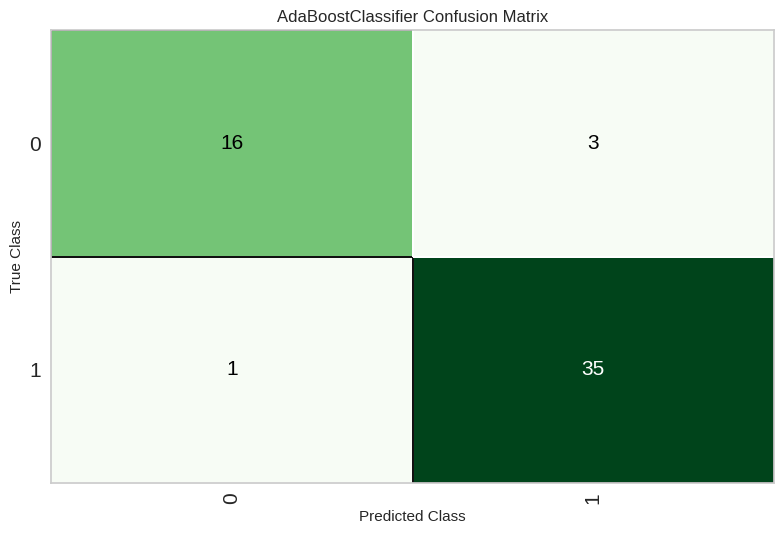

In [13]:
# Confusion Matrix

exp2.plot_model(tuned_model2, plot='confusion_matrix')

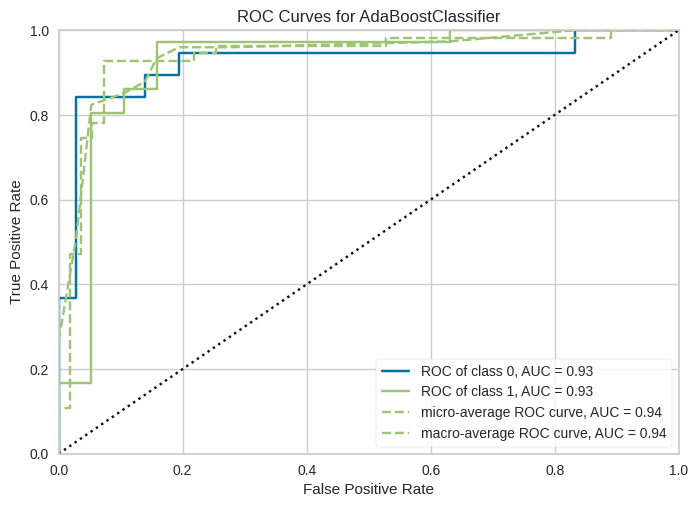

In [14]:
# ROC Curve

exp2.plot_model(tuned_model2, plot='auc')

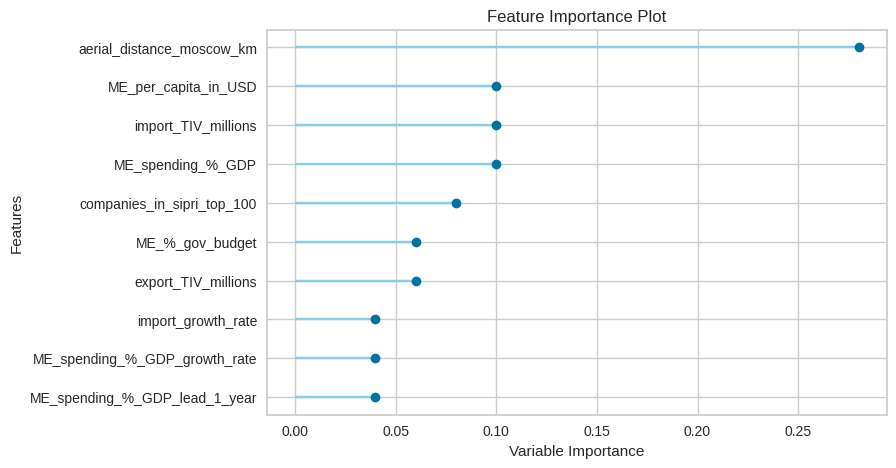

In [15]:
# Features that matter most

exp2.plot_model(tuned_model2, plot='feature')

In [16]:
# Interactive Evaluation Interface Dashboard

exp2.evaluate_model(tuned_model2)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…